# **Personalized Movie Recommendation System Using Collaboative Filtering**

---





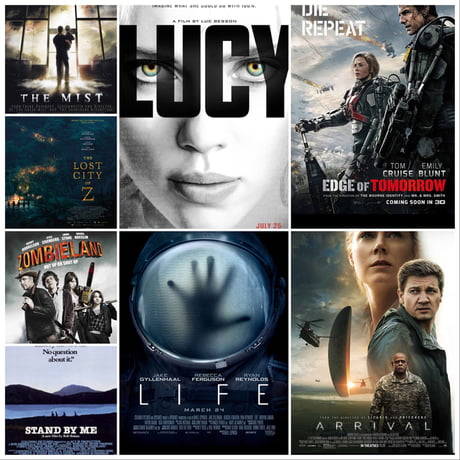

This project develops a **movie recommendation system** designed to improve user engagement and satisfaction on a streaming platform. The primary stakeholder is a product manager seeking to enhance personalized content delivery using user interaction data. The dataset consists of two main sources: a ratings dataset containing user-movie interactions and a movies dataset providing metadata such as titles and genres. These datasets are well-suited for the problem as they capture both user preferences and item characteristics, enabling multiple recommendation strategies.

**Data preparation** involved merging the datasets on a common movie identifier, handling missing values, and removing duplicates to ensure data quality. Feature engineering was applied to extract useful information from genres and compute aggregated statistics such as average ratings and rating counts. Python libraries including pandas and numpy were used for data manipulation, while scikit-learn supported preprocessing tasks.

Three recommendation models were implemented. A popularity-based model provided a baseline by recommending highly rated movies. A content-based filtering model used genre similarity to suggest similar items. Finally, a collaborative filtering model leveraged user rating patterns to generate personalized recommendations. The collaborative filtering approach was implemented using advanced techniques suitable for recommendation systems.

**Model evaluation** was conducted using appropriate validation strategies, including train-test splitting and performance metrics such as RMSE for rating prediction. Additionally, qualitative evaluation was performed by examining recommendation outputs. The final model demonstrated the ability to generate relevant and personalized recommendations. Limitations include data sparsity and cold-start problems. Future improvements could involve incorporating additional user or item features to enhance performance.

**Dataset Overview**

The movies dataset contains information about movie titles and genres.
It includes 86,537 entries with no missing values, making it clean and suitable
for content-based recommendation.

The ratings dataset contains over 33 million user ratings, which will be used
to understand user preferences and build collaborative filtering models.

# Data Understanding

In [ ]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from scipy.sparse.linalg import svds
from scipy.sparse import csc_matrix


In [ ]:
#loading the dataset (movies)
movies = pd.read_csv("data/movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [ ]:
#loading the dataset (ratings)
ratings = pd.read_csv('data/ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


# Data Cleaning

### Checked for null and duplicate values

In [ ]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [ ]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [ ]:
movies.duplicated().sum()

0

In [ ]:
ratings.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

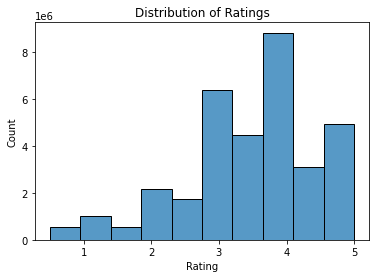

In [ ]:
#Rating distribution

plt.figure()
sns.histplot(ratings['rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Most ratings are concentrated between 3 and 5, indicating that users generally give positive feedback to movies. Low ratings are relatively rare, suggesting a bias toward higher ratings in the dataset.

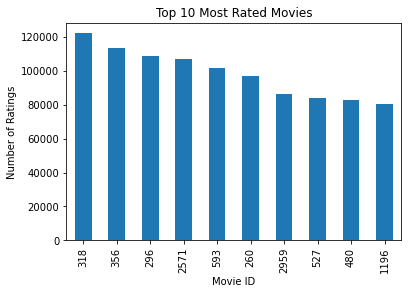

In [ ]:
#Most popular movies
movie_counts = ratings['movieId'].value_counts().head(10)

movie_counts.plot(kind='bar')
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

A small number of movies receive a very high number of ratings, indicating that popularity is highly skewed. This suggests that some movies dominate user attention, which is important for building a popularity-based recommendation system.

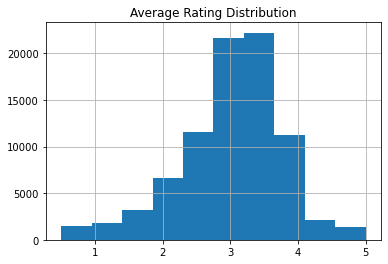

In [ ]:
#Average rating per movie
avg_rating = ratings.groupby('movieId')['rating'].mean()

avg_rating.hist()
plt.title("Average Rating Distribution")
plt.show()

Most movies have average ratings between 2.5 and 4, indicating moderate to high user satisfaction. Very few movies have extremely low or extremely high average ratings.

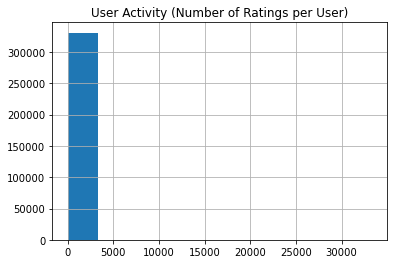

In [ ]:
#Number of ratings per user
user_counts = ratings['userId'].value_counts()

user_counts.hist()
plt.title("User Activity (Number of Ratings per User)")
plt.show()

Most users have rated only a small number of movies, while a few users are highly active. This indicates a sparse dataset, which can impact collaborative filtering performance.

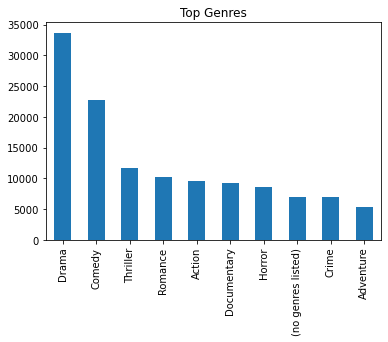

In [ ]:
#Genre analysis
movies['genres'] = movies['genres'].str.split('|')

from collections import Counter

all_genres = movies['genres'].explode()
genre_counts = Counter(all_genres)

pd.Series(genre_counts).sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

Drama and Comedy are the most common genres, indicating that these categories dominate the dataset. This information is useful for content-based recommendation, as genre plays a key role in similarity between movies.